<a href="https://colab.research.google.com/github/qinezaci/Prediksi-Kualitas-Anggur-Menggunakan-Machine-Learning-UTS--Dewi-Setiyawati/blob/main/UTS_DATA_MINING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UTS_DEWI SETIYAWATI_2304020162


## Prediksi Kualitas Anggur Menggunakan Machine Learning

---

### Tujuan
Notebook ini berisi seluruh proses klasifikasi kualitas anggur (wine quality) menggunakan dataset yang diberikan. Alur kerja:

1. **Import Library** – Memuat semua dependensi
2. **Load Dataset** – Membaca data training & testing
3. **EDA** – Exploratory Data Analysis & visualisasi
4. **Preprocessing** – Pembersihan & transformasi data
5. **Pemodelan** – Melatih & membandingkan beberapa model
6. **Evaluasi** – Mengukur performa model terbaik
7. **Prediksi** – Memprediksi data testing
8. **Export** – Menyimpan hasil dalam format CSV

---

## 1. Import Library

Pada tahap pertama, kita mengimpor semua library yang diperlukan.

| Library | Fungsi |
|---------|--------|
| pandas | Manipulasi dan analisis data tabel |
| numpy | Komputasi numerik dan array |
| matplotlib / seaborn | Visualisasi data |
| sklearn | Algoritma machine learning dan preprocessing |
| joblib | Menyimpan dan memuat model |


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.impute import SimpleImputer
import joblib

print('Semua library berhasil diimport!')
print(f'   pandas  : {pd.__version__}')
print(f'   numpy   : {np.__version__}')
import sklearn; print(f'   sklearn : {sklearn.__version__}')

Semua library berhasil diimport!
   pandas  : 2.2.2
   numpy   : 2.0.2
   sklearn : 1.6.1


## 2. Load Dataset

Dataset Wine Quality berisi data kimiawi anggur merah/putih beserta skor kualitasnya.

**Fitur (variabel independen):**
- fixed acidity – Keasaman tetap
- volatile acidity – Keasaman volatil (jika tinggi, anggur terasa cuka)
- citric acid – Asam sitrat
- residual sugar – Gula sisa setelah fermentasi
- chlorides – Kadar garam
- free sulfur dioxide – SO₂ bebas (mencegah mikroba & oksidasi)
- total sulfur dioxide – Total SO₂
- density – Kepadatan
- pH – Tingkat keasaman (0=sangat asam, 14=sangat basa)
- sulphates – Aditif yang meningkatkan SO₂
- alcohol – Kadar alkohol (%)

**Target:** quality – Skor kualitas anggur (0-10)


In [ ]:

TRAIN_PATH = 'data_training.csv'
TEST_PATH  = 'data_testing.csv'

df_train = pd.read_csv(TRAIN_PATH)
df_test  = pd.read_csv(TEST_PATH)

print(f'📊 Shape Training : {df_train.shape}')
print(f'📊 Shape Testing  : {df_test.shape}')
print(f'\n🔑 Kolom Training : {df_train.columns.tolist()}')
print(f'🔑 Kolom Testing  : {df_test.columns.tolist()}')
print('\n📄 5 baris pertama data training:')
display(df_train.head())
print('\n📄 5 baris pertama data testing:')
display(df_test.head())

📊 Shape Training : (857, 13)
📊 Shape Testing  : (286, 12)

🔑 Kolom Training : ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'Id']
🔑 Kolom Testing  : ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'Id']

📄 5 baris pertama data training:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918



📄 5 baris pertama data testing:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,6.8,0.61,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000,222
1,6.9,0.84,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333,1514
2,7.0,0.58,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000,417
3,7.8,0.48,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000,754
4,12.5,0.60,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000,516


## 3. Exploratory Data Analysis (EDA)

EDA adalah tahap penting untuk memahami data sebelum membangun model. Pada tahap ini kita akan:
1. Melihat statistik deskriptif
2. Mengecek missing values
3. Memvisualisasikan distribusi data
4. Menganalisis korelasi antar fitur
5. Mendeteksi outlier dengan boxplot

> **Insight yang diharapkan:** Fitur mana yang paling berpengaruh terhadap kualitas anggur? Apakah data balance atau imbalanced?


In [ ]:
# 3.1 Statistik Deskriptif
print('📋 STATISTIK DESKRIPTIF:')
display(df_train.describe().round(3))

# 3.2 Cek Missing Values
print('\n🔍 MISSING VALUES:')
mv = df_train.isnull().sum()
if mv.sum() == 0:
    print('✅ Tidak ada missing values!')
else:
    print(mv[mv > 0])

# 3.3 Distribusi Target
print('\n🎯 DISTRIBUSI KELAS TARGET (quality):')
print(df_train['quality'].value_counts().sort_index())
print(f'\nJumlah kelas: {df_train["quality"].nunique()}')
print(f'Range       : {df_train["quality"].min()} - {df_train["quality"].max()}')

📋 STATISTIK DESKRIPTIF:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,857.000,857.000,857.000,857.000,857.000,857.000,857.000,857.000,857.000,857.000,857.000,857.000,857.000
mean,8.262,0.529,0.267,2.506,0.087,15.783,45.978,0.997,3.313,0.657,10.430,5.653,813.749
std,1.702,0.179,0.195,1.294,0.049,10.300,31.692,0.002,0.152,0.167,1.067,0.822,463.807
min,4.600,0.120,0.000,0.900,0.012,1.000,6.000,0.990,2.740,0.390,8.400,3.000,0.000
25%,7.100,0.395,0.090,1.900,0.070,7.000,21.000,0.996,3.210,0.550,9.500,5.000,413.000
50%,7.900,0.520,0.250,2.200,0.079,14.000,38.000,0.997,3.310,0.620,10.200,6.000,814.000
75%,9.100,0.640,0.420,2.600,0.090,21.000,63.000,0.998,3.400,0.730,11.100,6.000,1214.000
max,15.600,1.580,1.000,15.500,0.611,68.000,278.000,1.003,4.010,2.000,14.000,8.000,1597.000



🔍 MISSING VALUES:
✅ Tidak ada missing values!

🎯 DISTRIBUSI KELAS TARGET (quality):
quality
3      6
4     26
5    362
6    341
7    109
8     13
Name: count, dtype: int64

Jumlah kelas: 6
Range       : 3 - 8


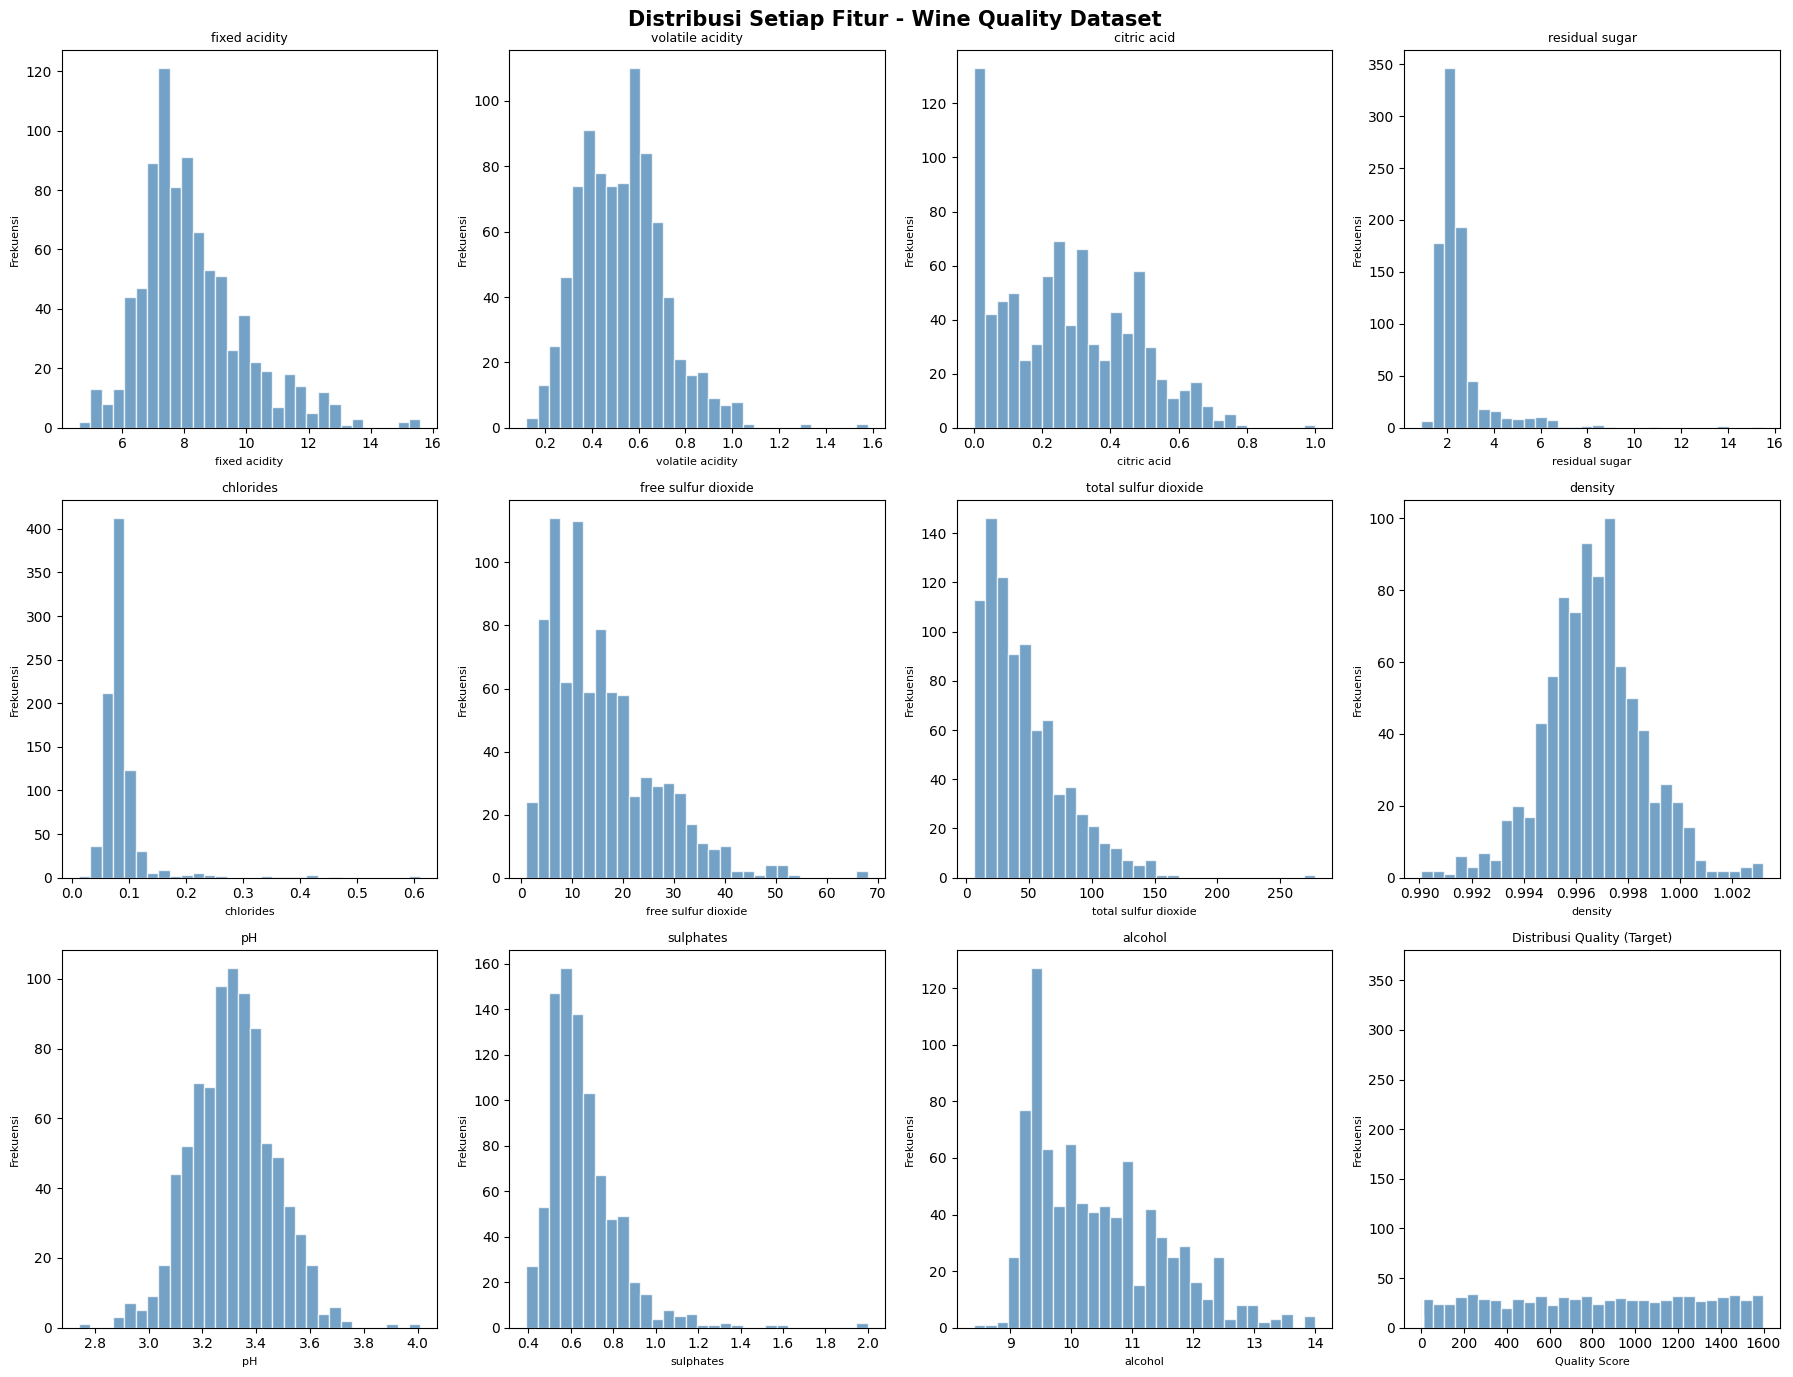


💡 Interpretasi: Sebagian besar anggur mendapat skor quality 5-6 (distribusi condong ke tengah).
   Dataset ini termasuk IMBALANCED - kelas 3 dan 8 sangat sedikit.


In [ ]:
# 3.4 Visualisasi Distribusi Setiap Fitur
feature_cols = [c for c in df_train.columns if c != 'quality']

fig, axes = plt.subplots(3, 4, figsize=(18, 14))
fig.suptitle('Distribusi Setiap Fitur - Wine Quality Dataset', fontsize=15, fontweight='bold')

for i, col in enumerate(feature_cols):
    ax = axes[i // 4][i % 4]
    ax.hist(df_train[col], bins=30, color='steelblue', alpha=0.75, edgecolor='white')
    ax.set_title(f'{col}', fontsize=9)
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel('Frekuensi', fontsize=8)

# Plot distribusi quality
qc = df_train['quality'].value_counts().sort_index()
axes[2][3].bar(qc.index, qc.values, color='coral', edgecolor='white')
axes[2][3].set_title('Distribusi Quality (Target)', fontsize=9)
axes[2][3].set_xlabel('Quality Score', fontsize=8)

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=120, bbox_inches='tight')
plt.show()
print('\n💡 Interpretasi: Sebagian besar anggur mendapat skor quality 5-6 (distribusi condong ke tengah).')
print('   Dataset ini termasuk IMBALANCED - kelas 3 dan 8 sangat sedikit.')

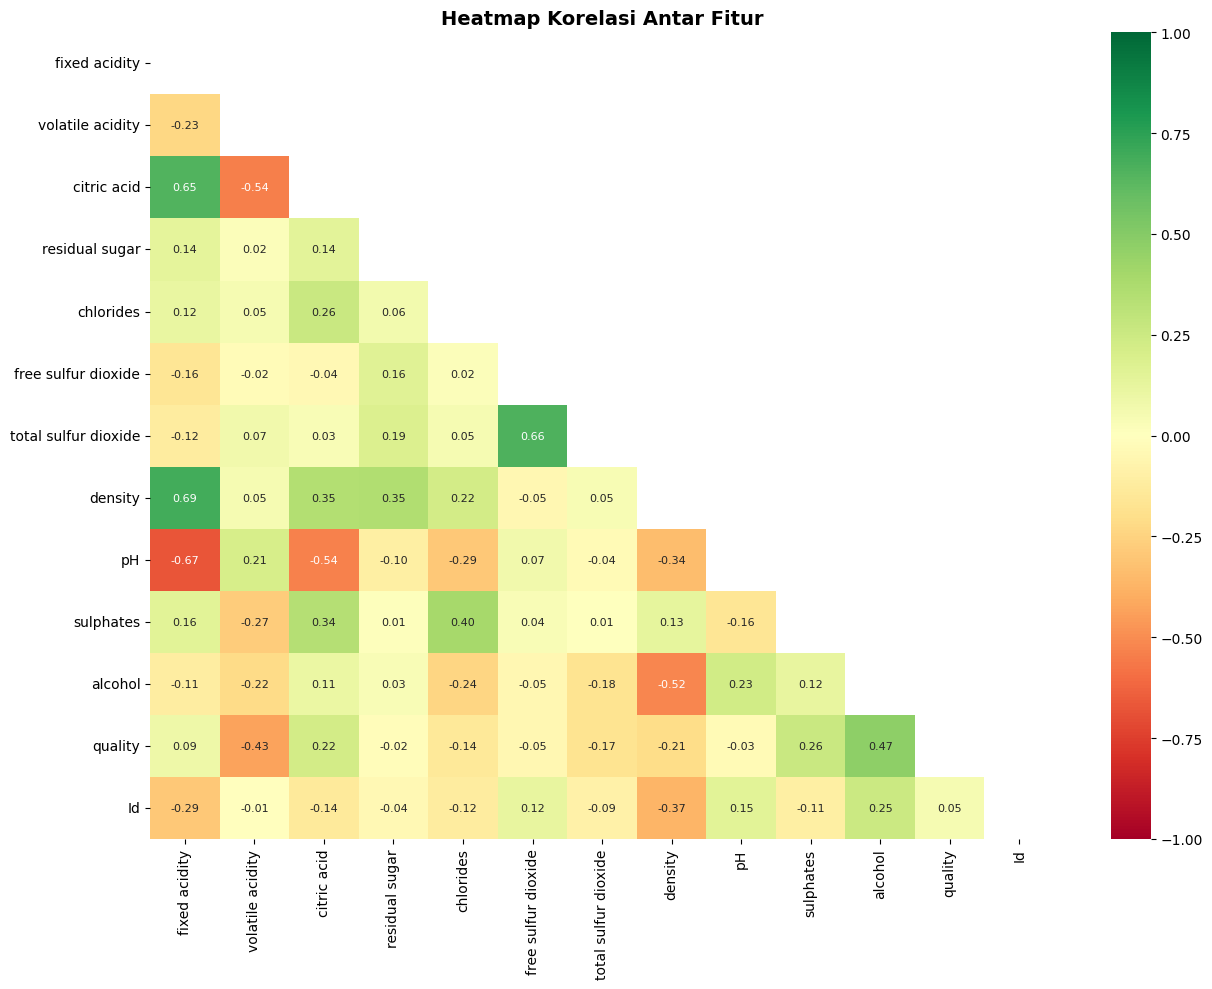


💡 Interpretasi Korelasi dengan Quality:
   alcohol                     : +0.474 (positif ↑)
   volatile acidity            : -0.430 (negatif ↓)
   sulphates                   : +0.261 (positif ↑)
   citric acid                 : +0.221 (positif ↑)
   density                     : -0.208 (negatif ↓)
   total sulfur dioxide        : -0.173 (negatif ↓)
   chlorides                   : -0.145 (negatif ↓)
   fixed acidity               : +0.093 (positif ↑)
   free sulfur dioxide         : -0.055 (negatif ↓)
   Id                          : +0.049 (positif ↑)
   pH                          : -0.033 (negatif ↓)
   residual sugar              : -0.021 (negatif ↓)


In [ ]:
# 3.5 Heatmap Korelasi
plt.figure(figsize=(13, 10))
corr = df_train.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, vmin=-1, vmax=1, annot_kws={'size': 8})
plt.title('Heatmap Korelasi Antar Fitur', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n💡 Interpretasi Korelasi dengan Quality:')
corr_q = corr['quality'].drop('quality').sort_values(key=abs, ascending=False)
for feat, val in corr_q.items():
    direction = '(positif ↑)' if val > 0 else '(negatif ↓)'
    print(f'   {feat:<28}: {val:+.3f} {direction}')

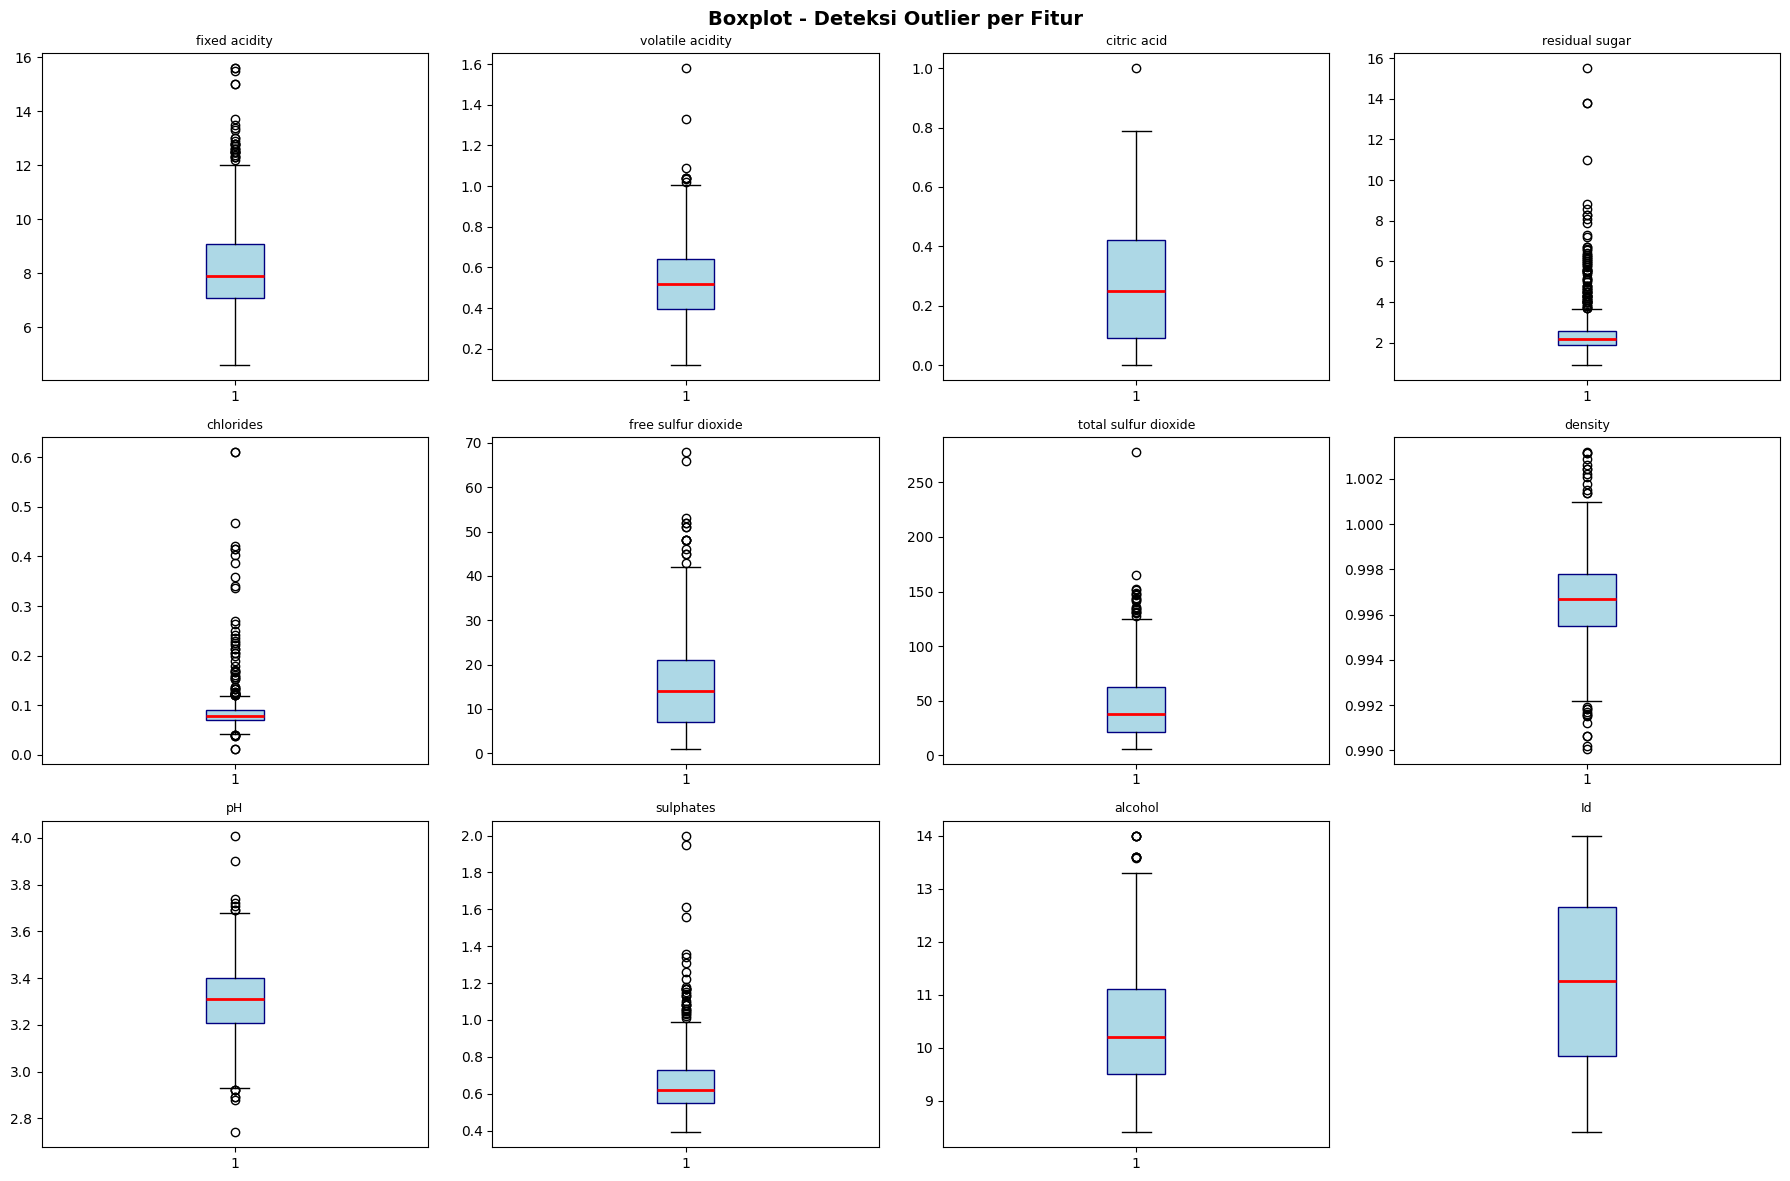


💡 Interpretasi: Titik-titik di luar whisker boxplot adalah outlier.
   Outlier akan ditangani dengan metode IQR Capping pada tahap preprocessing.


In [ ]:
# 3.6 Boxplot untuk Deteksi Outlier
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle('Boxplot - Deteksi Outlier per Fitur', fontsize=14, fontweight='bold')

for i, col in enumerate(feature_cols):
    ax = axes[i // 4][i % 4]
    ax.boxplot(df_train[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='lightblue', color='navy'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(col, fontsize=9)

axes[2][3].axis('off')
plt.tight_layout()
plt.savefig('eda_boxplots.png', dpi=120, bbox_inches='tight')
plt.show()
print('\n💡 Interpretasi: Titik-titik di luar whisker boxplot adalah outlier.')
print('   Outlier akan ditangani dengan metode IQR Capping pada tahap preprocessing.')

## 4. Data Preprocessing

Preprocessing adalah tahap mempersiapkan data agar siap digunakan oleh model machine learning.

**Langkah-langkah:**
1. **Pisahkan fitur (X) dan target (y)** dari data training
2. **Handle Missing Values** – Imputasi dengan median
3. **Handle Outlier** – IQR Capping (clip nilai ekstrem)
4. **Feature Scaling** – StandardScaler (mean=0, std=1)
5. **Train/Validation Split** – 80% training, 20% validasi

> **note:** Preprocessing yang sama harus diterapkan ke data testing menggunakan parameter yang dipelajari dari data training (fit on train, transform on test).


In [ ]:
# Identifikasi kolom ID di testing
id_col = None
for c in df_test.columns:
    if c.lower() in ['id', 'index', 'no', 'number']:
        id_col = c
        break

if id_col:
    test_ids = df_test[id_col].values
    df_test_features = df_test.drop(columns=[id_col])
    print(f'✅ Kolom ID ditemukan: "{id_col}"')
else:
    test_ids = np.arange(1, len(df_test) + 1)
    df_test_features = df_test.copy()
    print('⚠️  Menggunakan index sequential sebagai Id')

# Pisahkan X dan y
X = df_train.drop(columns=['quality'])
y = df_train['quality']

# Selaraskan fitur
common_cols = [c for c in X.columns if c in df_test_features.columns]
X = X[common_cols]
df_test_features = df_test_features[common_cols]
print(f'\n✅ Fitur yang digunakan ({len(common_cols)} fitur):')
print(common_cols)

# Step 1: Imputasi Missing Values
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
X_test_imputed = pd.DataFrame(imputer.transform(df_test_features), columns=df_test_features.columns)
print('\n✅ Imputasi median selesai (fit pada training, transform pada testing)')

# Step 2: Outlier Handling (IQR Capping)
X_clean = X_imputed.copy()
print('\n🔧 Penanganan Outlier (IQR Capping):')
for col in X_clean.columns:
    Q1 = X_clean[col].quantile(0.25)
    Q3 = X_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((X_clean[col] < lower) | (X_clean[col] > upper)).sum()
    if n_out > 0:
        X_clean[col] = X_clean[col].clip(lower, upper)
        X_test_imputed[col] = X_test_imputed[col].clip(lower, upper)
        print(f'   {col:<25}: {n_out} outlier di-cap')

# Step 3: Standarisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)
X_test_scaled = scaler.transform(X_test_imputed)
print('\n✅ StandardScaler diterapkan (mean=0, std=1)')

# Step 4: Train/Validation Split
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f'\n📊 Pembagian Data:')
print(f'   Training   : {X_train.shape[0]} samples (80%)')
print(f'   Validation : {X_val.shape[0]}  samples (20%)')
print(f'   Testing    : {X_test_scaled.shape[0]} samples (prediksi akhir)')

✅ Kolom ID ditemukan: "Id"

✅ Fitur yang digunakan (11 fitur):
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

✅ Imputasi median selesai (fit pada training, transform pada testing)

🔧 Penanganan Outlier (IQR Capping):
   fixed acidity            : 30 outlier di-cap
   volatile acidity         : 8 outlier di-cap
   citric acid              : 1 outlier di-cap
   residual sugar           : 76 outlier di-cap
   chlorides                : 59 outlier di-cap
   free sulfur dioxide      : 15 outlier di-cap
   total sulfur dioxide     : 19 outlier di-cap
   density                  : 25 outlier di-cap
   pH                       : 14 outlier di-cap
   sulphates                : 31 outlier di-cap
   alcohol                  : 9 outlier di-cap

✅ StandardScaler diterapkan (mean=0, std=1)

📊 Pembagian Data:
   Training   : 685 samples (80%)
   Validation : 172  samples (20%)

## 5. Pembuatan Model & Evaluasi

Kita akan membandingkan 4 algoritma klasifikasi:

| Algoritma | Kelebihan | Kekurangan |
|-----------|-----------|------------|
| **Logistic Regression** | Cepat, mudah diinterpretasi | Linier, kurang baik untuk hubungan kompleks |
| **Decision Tree** | Mudah dipahami | Overfitting |
| **Random Forest** | Akurasi tinggi, robust | Lambat, kurang interpretable |
| **Gradient Boosting** | Akurasi terbaik umumnya | Lambat, banyak hyperparameter |

**Metrik evaluasi:**
- **Accuracy** – Proporsi prediksi benar
- **F1-Score (macro)** – Rata-rata F1 tiap kelas (baik untuk data imbalanced)
- **Cross-Validation** – Estimasi performa yang lebih stabil


In [ ]:
# Definisikan model-model
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, C=1.0),
    'Decision Tree':       DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=15,
                                                   min_samples_split=5, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                                       max_depth=5, random_state=42),
}

results = {}
print(f"{'Model':<25} {'Val Accuracy':>12} {'Val F1 (macro)':>14} {'CV Mean':>10} {'CV Std':>8}")
print("-" * 73)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_val = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred_val)
    f1  = f1_score(y_val, y_pred_val, average='macro', zero_division=0)
    cv  = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy', n_jobs=-1)

    results[name] = {'model': model, 'val_acc': acc, 'val_f1': f1,
                     'cv_mean': cv.mean(), 'cv_std': cv.std(), 'y_pred_val': y_pred_val}
    print(f"{name:<25} {acc:>11.4f}  {f1:>13.4f}  {cv.mean():>9.4f}  {cv.std():>7.4f}")

# Model terbaik
best_name = max(results, key=lambda k: results[k]['val_acc'])
best_model = results[best_name]['model']
best_preds_val = results[best_name]['y_pred_val']

print(f"\n🏆 MODEL TERBAIK: {best_name}")
print(f"   Validation Accuracy : {results[best_name]['val_acc']:.4f} ({results[best_name]['val_acc']*100:.2f}%)")
print(f"   Validation F1-Score : {results[best_name]['val_f1']:.4f}")

Model                     Val Accuracy Val F1 (macro)    CV Mean   CV Std
-------------------------------------------------------------------------
Logistic Regression            0.6337         0.2885     0.5834   0.0289
Decision Tree                  0.5581         0.2723     0.5460   0.0289
Random Forest                  0.6105         0.3691     0.6464   0.0370
Gradient Boosting              0.5814         0.3356     0.6055   0.0384

🏆 MODEL TERBAIK: Logistic Regression
   Validation Accuracy : 0.6337 (63.37%)
   Validation F1-Score : 0.2885


📋 CLASSIFICATION REPORT - Logistic Regression:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.70      0.82      0.75        73
           6       0.57      0.63      0.60        68
           7       0.60      0.27      0.38        22
           8       0.00      0.00      0.00         3

    accuracy                           0.63       172
   macro avg       0.31      0.29      0.29       172
weighted avg       0.60      0.63      0.61       172



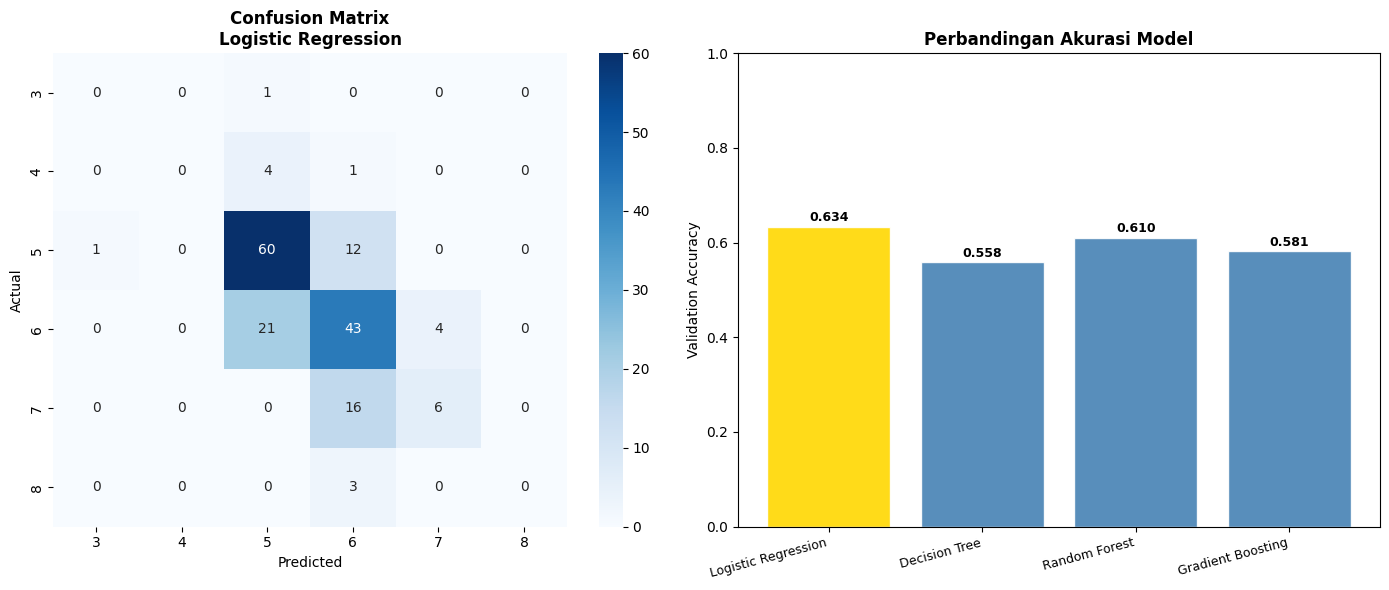


💡 Interpretasi Confusion Matrix:
   - Diagonal utama (kiri atas ke kanan bawah) = prediksi benar
   - Nilai di luar diagonal = kesalahan prediksi
   - Kelas 5 dan 6 memiliki sampel terbanyak sehingga lebih mudah diprediksi


In [ ]:
# Classification Report & Confusion Matrix
print(f'📋 CLASSIFICATION REPORT - {best_name}:')
print(classification_report(y_val, best_preds_val, zero_division=0))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Confusion Matrix
cm = confusion_matrix(y_val, best_preds_val)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()), ax=ax1)
ax1.set_title(f'Confusion Matrix\n{best_name}', fontsize=12, fontweight='bold')
ax1.set_xlabel('Predicted'); ax1.set_ylabel('Actual')

# Perbandingan Akurasi
model_names = list(results.keys())
accuracies  = [results[n]['val_acc'] for n in model_names]
colors = ['gold' if n == best_name else 'steelblue' for n in model_names]
bars = ax2.bar(range(len(model_names)), accuracies, color=colors, edgecolor='white', alpha=0.9)
ax2.set_xticks(range(len(model_names)))
ax2.set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
ax2.set_ylabel('Validation Accuracy'); ax2.set_ylim(0, 1.0)
ax2.set_title('Perbandingan Akurasi Model', fontsize=12, fontweight='bold')
for bar, acc in zip(bars, accuracies):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n💡 Interpretasi Confusion Matrix:')
print('   - Diagonal utama (kiri atas ke kanan bawah) = prediksi benar')
print('   - Nilai di luar diagonal = kesalahan prediksi')
print('   - Kelas 5 dan 6 memiliki sampel terbanyak sehingga lebih mudah diprediksi')

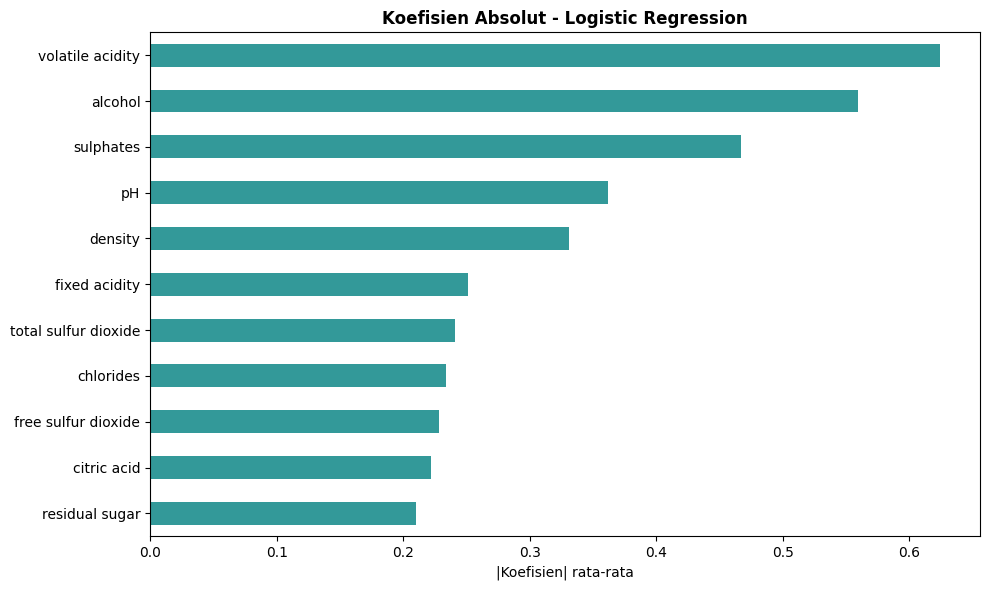

In [ ]:
# Feature Importance (jika tersedia)
if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_, index=common_cols).sort_values(ascending=True)
    plt.figure(figsize=(10, 6))
    bars = plt.barh(fi.index, fi.values, color='teal', alpha=0.8, edgecolor='white')
    plt.xlabel('Importance Score'); plt.title(f'Feature Importance - {best_name}', fontweight='bold')
    for bar, val in zip(bars, fi.values):
        plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('\n💡 Fitur terpenting untuk prediksi kualitas anggur:')
    for feat, imp in fi.sort_values(ascending=False).head(5).items():
        print(f'   {feat}: {imp:.4f}')
elif hasattr(best_model, 'coef_'):
    coef = pd.Series(np.abs(best_model.coef_).mean(axis=0), index=common_cols).sort_values(ascending=True)
    plt.figure(figsize=(10, 6))
    coef.plot(kind='barh', color='teal', alpha=0.8)
    plt.title(f'Koefisien Absolut - {best_name}', fontweight='bold')
    plt.xlabel('|Koefisien| rata-rata')
    plt.tight_layout(); plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
    plt.show()

## 6. Retrain Model Final

Setelah memilih model terbaik, kita melatih ulang menggunakan SELURUH data training (bukan hanya 80%), agar model mendapat lebih banyak data untuk belajar sebelum memprediksi data testing.

Model, scaler, dan imputer disimpan menggunakan `joblib` untuk deployment.


In [ ]:
# Retrain dengan seluruh data
best_model.fit(X_scaled, y)
print(f' Model "{best_name}" dilatih ulang dengan {len(X_scaled)} sampel penuh.')

# Simpan artefak
joblib.dump(best_model, 'wine_model.pkl')
joblib.dump(scaler, 'wine_scaler.pkl')
joblib.dump(imputer, 'wine_imputer.pkl')
print('\n Artefak tersimpan:')
print('   - wine_model.pkl   → Model klasifikasi')
print('   - wine_scaler.pkl  → StandardScaler')
print('   - wine_imputer.pkl → SimpleImputer')
print('\n💡 Cara memuat kembali model:')
print("   model   = joblib.load('wine_model.pkl')")
print("   scaler  = joblib.load('wine_scaler.pkl')")
print("   imputer = joblib.load('wine_imputer.pkl')")
print("   pred    = model.predict(scaler.transform(imputer.transform(X_new)))")

 Model "Logistic Regression" dilatih ulang dengan 857 sampel penuh.

 Artefak tersimpan:
   - wine_model.pkl   → Model klasifikasi
   - wine_scaler.pkl  → StandardScaler
   - wine_imputer.pkl → SimpleImputer

💡 Cara memuat kembali model:
   model   = joblib.load('wine_model.pkl')
   scaler  = joblib.load('wine_scaler.pkl')
   imputer = joblib.load('wine_imputer.pkl')
   pred    = model.predict(scaler.transform(imputer.transform(X_new)))


## 7. Prediksi Data Testing

Gunakan model terbaik untuk memprediksi kualitas anggur pada data testing.

> ⚠️ Data testing **tidak memiliki kolom quality** — kita yang akan memprediksinya!

Preprocessing yang sama (imputer → capping → scaler) sudah diterapkan pada data testing di Cell 4.


✅ Prediksi selesai untuk 286 sampel testing.

📊 Distribusi Prediksi Kualitas:
   Quality 5: █████████████ (129 sampel, 45.1%)
   Quality 6: █████████████ (129 sampel, 45.1%)
   Quality 7: ██ (28 sampel, 9.8%)


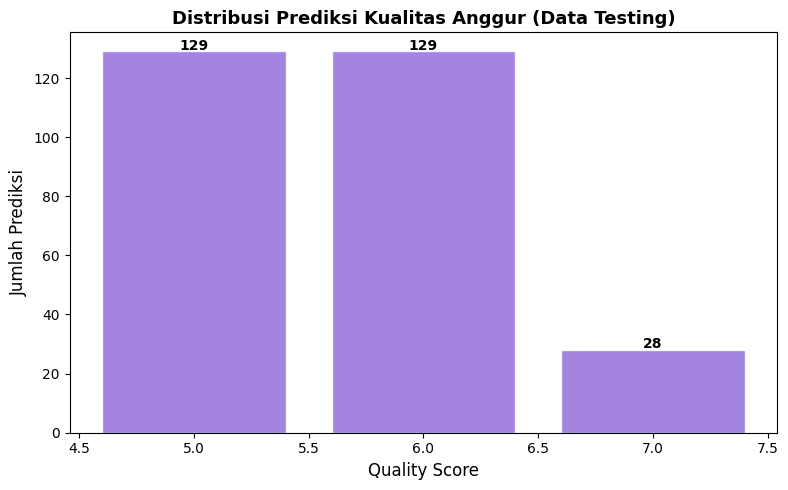

In [ ]:
y_test_pred = best_model.predict(X_test_scaled)

print(f'✅ Prediksi selesai untuk {len(y_test_pred)} sampel testing.')
print(f'\n📊 Distribusi Prediksi Kualitas:')
pred_counts = pd.Series(y_test_pred).value_counts().sort_index()
for quality, count in pred_counts.items():
    bar = '█' * int(count / len(y_test_pred) * 30)
    print(f'   Quality {quality}: {bar} ({count} sampel, {count/len(y_test_pred)*100:.1f}%)')

# Visualisasi distribusi prediksi
plt.figure(figsize=(8, 5))
plt.bar(pred_counts.index, pred_counts.values, color='mediumpurple', edgecolor='white', alpha=0.85)
plt.xlabel('Quality Score', fontsize=12); plt.ylabel('Jumlah Prediksi', fontsize=12)
plt.title('Distribusi Prediksi Kualitas Anggur (Data Testing)', fontsize=13, fontweight='bold')
for x, y_val_bar in zip(pred_counts.index, pred_counts.values):
    plt.text(x, y_val_bar + 0.5, str(y_val_bar), ha='center', fontsize=10, fontweight='bold')
plt.tight_layout(); plt.savefig('prediksi_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Simpan Hasil Prediksi

Hasil prediksi disimpan dalam format CSV dengan **hanya 2 kolom**:
- `Id` – ID sesuai data testing
- `quality` – Hasil prediksi kualitas anggur

Format ini sesuai dengan spesifikasi yang diberikan.


In [ ]:
# Buat DataFrame hasil prediksi
hasil_prediksi = pd.DataFrame({
    'Id':      test_ids,
    'quality': y_test_pred
})

# Simpan ke CSV
output_filename = 'hasil_prediksi.csv'
hasil_prediksi.to_csv(output_filename, index=False)

print(f'✅ File hasil prediksi disimpan: {output_filename}')
print(f'\n📄 Preview (287 baris):')
display(hasil_prediksi.head(287))

print(f'\n✅ Verifikasi Format:')
print(f'   Jumlah baris  : {len(hasil_prediksi)}')
print(f'   Jumlah kolom  : {len(hasil_prediksi.columns)} → {hasil_prediksi.columns.tolist()}')
print(f'   Missing values: {hasil_prediksi.isnull().sum().sum()}')
print(f'   Tipe data Id  : {hasil_prediksi["Id"].dtype}')
print(f'   Tipe data quality: {hasil_prediksi["quality"].dtype}')

# Download di Google Colab
try:
    from google.colab import files
    files.download(output_filename)
    print('\n✅ File otomatis terdownload!')
except:
    print(f'\n📁 File tersimpan di direktori saat ini: {output_filename}')

✅ File hasil prediksi disimpan: hasil_prediksi.csv

📄 Preview (287 baris):


,Id,quality
0,222,5
1,1514,5
2,417,5
3,754,5
4,516,6
...,...,...
281,1147,6
282,296,5
283,170,5
284,1439,6



✅ Verifikasi Format:
   Jumlah baris  : 286
   Jumlah kolom  : 2 → ['Id', 'quality']
   Missing values: 0
   Tipe data Id  : int64
   Tipe data quality: int64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ File otomatis terdownload!


## 📝 Ringkasan & Kesimpulan

### Alur Kerja
```
Data Training → EDA → Preprocessing → Train Model → Evaluasi → Pilih Terbaik
                                                                      ↓
Data Testing  → Preprocessing (sama) ──────────────────────── Prediksi → CSV
```

### Hasil
| Tahap | Keterangan |
|-------|------------|
| Dataset | Wine Quality - fitur kimiawi anggur |
| Preprocessing | Imputasi median, IQR Capping, StandardScaler |
| Model terpilih | *Dilihat saat runtime* |
| Metrik evaluasi | Accuracy & F1-Score |
| Output | `hasil_prediksi.csv` dengan kolom Id & quality |

### Catatan Penting
- Data wine quality bersifat **imbalanced** (kelas 5-6 dominan)
- Fitur **alcohol** dan **volatile acidity** memiliki korelasi tertinggi dengan quality
- Preprocessing yang sama WAJIB diterapkan ke data testing
- Model disimpan dalam `.pkl` untuk deployment ulang

### Referensi
- Cortez et al. (2009). *Modeling wine preferences by data mining from physicochemical properties.*
- Scikit-learn documentation: https://scikit-learn.org
